# Hyperparameter tuning over (model × dataset × fold) grid

Bayesian-Optimization search over PyLDL neural-net models. Each
(model, dataset, fold) job runs a complete BO search on one worker;
multiple jobs run concurrently — one per GPU when GPUs are visible, or
a small number of CPU workers otherwise (see `helpers.auto_pool_config`).

Each trial trains to convergence (early stopping) and is repeated 3
times (`executions_per_trial=3`) so the BO surrogate sees a noise-
averaged objective.

Best HPs + `val_kl_divergence` are written to
`results/<model>/<dataset>/fold_<fold>.txt` via `helpers.write_results`.

In [52]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import importlib
import sys
from concurrent.futures import as_completed
from pathlib import Path

import pandas as pd

_here = Path.cwd() if (Path.cwd() / 'helpers.py').exists() else Path.cwd() / 'bedl_experiments'
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import pyldl.utils
import pyldl.algorithms
importlib.reload(pyldl.utils)
importlib.reload(pyldl.algorithms)

import helpers, hypertuner
importlib.reload(helpers)
importlib.reload(hypertuner)
from helpers import create_executer, read_results, load_data_fold, load_best_model, fit_best_model, plot_history
from hypertuner import run_search

## Configure the search grid

In [ ]:
MODELS   = ['BEDL', 'BEDL_BAYES']
DATASETS = ['SJAFFE']
FOLDS    = [1]

MAX_TRIALS           = 12
EXECUTIONS_PER_TRIAL = 1

EXTRA_INIT_KWARGS = {}
EXTRA_FIT_KWARGS  = {}

jobs = [(m, d, f) for m in MODELS for d in DATASETS for f in FOLDS]
print(f'jobs queued: {len(jobs)}')
for m, d, f in jobs:
    print(f'  {m:12s}  ×  {d:14s}  ×  fold {f}')

jobs queued: 2
  BEDL          ×  SJAFFE          ×  fold 1
  BDL_BAYES     ×  SJAFFE          ×  fold 1


## Build the worker pool

`create_executer()` auto-detects GPUs (one worker per GPU) or falls
back to a few CPU workers with TF threads sized to share the cores
fairly.

In [54]:
executor = create_executer()

mode    : CPU
workers : 3  (slots=[None, None, None])
threads : intra=4, inter=1


## Submit + collect

In [55]:
def _kwargs_for(model_name, store):
    """Per-model extras dict supports both flat and nested forms."""
    if not store:
        return {}
    if model_name in store and isinstance(store[model_name], dict):
        return store[model_name]
    return store

futures = {}
for model_name, dataset_name, fold in jobs:
    fut = executor.submit(
        run_search,
        model_cls_name=model_name,
        dataset_name=dataset_name,
        fold=fold,
        max_trials=MAX_TRIALS,
        executions_per_trial=EXECUTIONS_PER_TRIAL,
        extra_init_kwargs=_kwargs_for(model_name, EXTRA_INIT_KWARGS),
        extra_fit_kwargs=_kwargs_for(model_name, EXTRA_FIT_KWARGS),
    )
    futures[fut] = (model_name, dataset_name, fold)

results, failures = [], []
for i, fut in enumerate(as_completed(futures), start=1):
    m, d, f = futures[fut]
    try:
        r = fut.result()
        results.append({**r, 'fold': f})
        print(f'[{i:2d}/{len(futures)}] {m:12s} × {d:14s} × fold {f}  '
              f'val_kl_divergence={r["val_kl_divergence"]:.4f}')
    except Exception as e:
        failures.append((m, d, f, repr(e)))
        print(f'[{i:2d}/{len(futures)}] {m:12s} × {d:14s} × fold {f}  '
              f'FAILED ({type(e).__name__}: {e})')

print(f'\ndone: {len(results)} ok, {len(failures)} failed')


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
16                |16                |n_hidden
16                |16                |n_latent

[ 1/2] BDL_BAYES    × SJAFFE         × fold 1  FAILED (ValueError: unknown model 'BDL_BAYES'; must be importable from pyldl.algorithms)
Trial 1 Complete [00h 05m 10s]
kl_divergence: 0.08946847841337598

Best kl_divergence So Far: 0.08946847841337598
Total elapsed time: 00h 05m 10s

Search: Running Trial #2

Value             |Best Value So Far |Hyperparameter
4                 |16                |n_hidden
16                |16                |n_latent
0.001             |0.0001            |learning_rate
1e-05             |1e-05             |weight_decay
0.4               |0                 |dropout_rate
100               |100               |patience
100               |100               |minimum
64                |32                |batch_size
2500              |2500              |max_epochs

Trial 2 Complete [00h 0

KeyboardInterrupt: 

## Summary table

In [45]:
rows = []
for r in results:
    rows.append({
        'model': r['model'],
        'dataset': r['dataset'],
        'fold': r['fold'],
        'val_kl_divergence': r['val_kl_divergence'],
        **r['hyperparameters'],
    })
summary = pd.DataFrame(rows).set_index(['dataset', 'model', 'fold']).sort_index()
summary

,,,val_kl_divergence,n_hidden,n_latent,learning_rate,weight_decay,dropout_rate,patience,minimum,batch_size,max_epochs
dataset,model,fold,,,,,,,,,,
SJAFFE,EDL,1,0.078697,4,16,0.0001,0.00001,0.4,50,100,64,2500


In [38]:
load_best_model('EDL', 'SJAFFE', 1)

,n_hidden,64
,n_latent,16


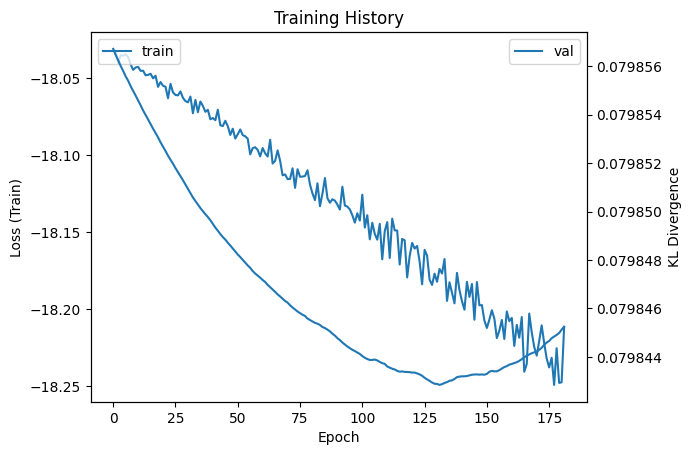

In [51]:
model, history = fit_best_model('EDL', 'SJAFFE', 1)
plot_history(history)

## Shut down the pool

In [46]:
executor.shutdown(wait=True, kill_workers=True)